# Final Engineering Results
Identification of the Pareto Optimal designs and selection of the best trade-off candidate from the experimental dataset.

Loaded 92 samples from Elips0
Selection Logic: Min Volume with Strength >= 70.0 kN

--- OPTIMAL DESIGN (CATEGORY 0) ---
ID: Specimen_47
Strength: 71.20 kN
Volume:   213.28 mm3
Geometry (a_i): [5.0, 6.0, 7.0, 8.0, 9.0, 11.0]
Geometry (b_i): [5, 6.0, 7.0, 8.0, 9.0, 10.0]


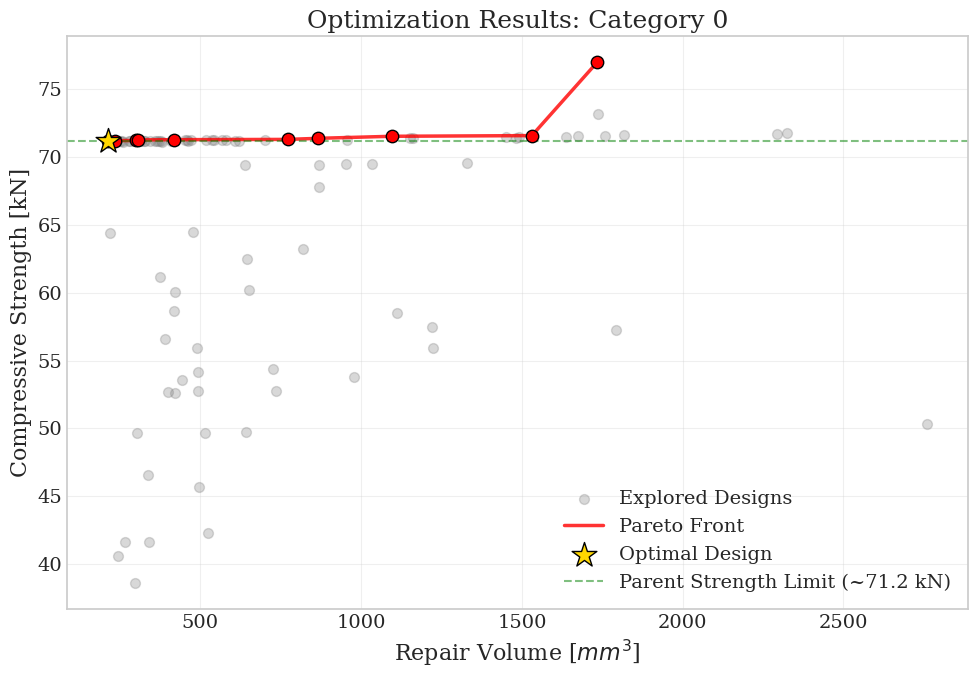

In [44]:
# %% [markdown]
# # Final Engineering Results (Physics-Based Selection)
# Logic: Since strength saturates at the parent limit (~71.2 kN), the 'Best' design is defined as the Minimum Volume configuration that achieves full strength recovery (> 70 kN).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": (10, 7)
})

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- HELPER FUNCTIONS ---

def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3)."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def get_pareto_front(df):
    """Identifies Pareto efficient points."""
    costs = df[['Volume_mm3', 'Strength']].values.copy()
    costs[:, 1] = -costs[:, 1] 
    
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0
    
    while next_point_index < len(costs):
        nondominated_point_mask = np.any(costs < costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index]) + 1
        
    mask = np.zeros(n_points, dtype=bool)
    mask[is_efficient] = True
    return mask

def find_best_physics_design(df_pareto, strength_threshold=70.0):
    """
    Finds the Best Design based on Physical Saturation.
    Criteria:
    1. Must have Strength >= Threshold (Full Recovery).
    2. Minimize Volume among those candidates.
    """
    # Filter for full strength recovery
    high_strength = df_pareto[df_pareto['Strength'] >= strength_threshold]
    
    if len(high_strength) > 0:
        # Pick smallest volume among the strong ones
        best_design = high_strength.sort_values('Volume_mm3').iloc[0]
        print(f"Selection Logic: Min Volume with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just pick the absolute strongest point found
        best_design = df_pareto.sort_values('Strength', ascending=False).iloc[0]
        print(f"Selection Logic: Fallback (Max Strength) - Threshold {strength_threshold} kN not met.")
        
    return best_design

# --- EXECUTION FOR CATEGORY 0 ---
CATEGORY = 0
file_path = 'Data_v4.xlsx'
sheet_name = f'Elips{CATEGORY}'

# 1. Load Data
try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df.dropna(subset=['Strength']) 
    print(f"Loaded {len(df)} samples from {sheet_name}")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Calculate Volume (Corrected with Ply Thickness)
    ply_thickness = config['OPTIMIZATION']['THICKNESS_CONSTANT']
    if 'Volume' not in df.columns or df['Volume'].isna().all():
        df['Volume_mm3'] = calculate_volume(df, ply_thickness=ply_thickness)
    else:
        df['Volume_mm3'] = df['Volume']

    # 3. Identify Pareto Front
    df['is_pareto'] = get_pareto_front(df)
    pareto_set = df[df['is_pareto']].sort_values('Volume_mm3')

    # 4. Find Best Candidate (Physics Strategy)
    # Threshold set to 70.0 kN based on parent strength saturation ~71.2
    best_design = find_best_physics_design(pareto_set, strength_threshold=70.0)

    print(f"\n--- OPTIMAL DESIGN (CATEGORY {CATEGORY}) ---")
    print(f"ID: {best_design.get('Specimen_ID', 'Unknown')}")
    print(f"Strength: {best_design['Strength']:.2f} kN")
    print(f"Volume:   {best_design['Volume_mm3']:.2f} mm3")
    print("Geometry (a_i):", [best_design[f'a_ply{i}'] for i in range(1,7)])
    print("Geometry (b_i):", [best_design[f'b_ply{i}'] for i in range(1,7)])

    # --- PLOTTING ---
    plt.figure(figsize=(10, 7))

    # Plot All Points
    plt.scatter(df['Volume_mm3'], df['Strength'], 
                c='gray', alpha=0.3, s=50, label='Explored Designs')

    # Plot Pareto Front
    plt.plot(pareto_set['Volume_mm3'], pareto_set['Strength'], 
             'r-', lw=2.5, alpha=0.8, label='Pareto Front')
    plt.scatter(pareto_set['Volume_mm3'], pareto_set['Strength'], 
                c='red', s=80, edgecolors='k', zorder=5)

    # Highlight Best Point
    plt.scatter(best_design['Volume_mm3'], best_design['Strength'], 
                c='gold', marker='*', s=350, edgecolors='k', zorder=10, 
                label='Optimal Design')
    
    # Draw Threshold Line
    plt.axhline(y=71.2, color='green', linestyle='--', alpha=0.5, label='Parent Strength Limit (~71.2 kN)')

    plt.xlabel('Repair Volume [$mm^3$]')
    plt.ylabel('Compressive Strength [kN]')
    plt.title(f'Optimization Results: Category {CATEGORY}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'final_result_cat{CATEGORY}_physics.png', dpi=300)
    plt.show()

Loaded 78 samples from Elips1
Selection Logic: Min Volume with Strength >= 70.0 kN

--- OPTIMAL DESIGN (CATEGORY 1) ---
ID: Specimen_87
Strength: 71.20 kN
Volume:   259.45 mm3
Ratio R:  0.2744 kN/mm3
Geometry (a_i): [5.0, 6.0, 7.0, 10.0, 11.0, 12.0]
Geometry (b_i): [5, 6.0, 7.0, 8.0, 10.0, 12.0]


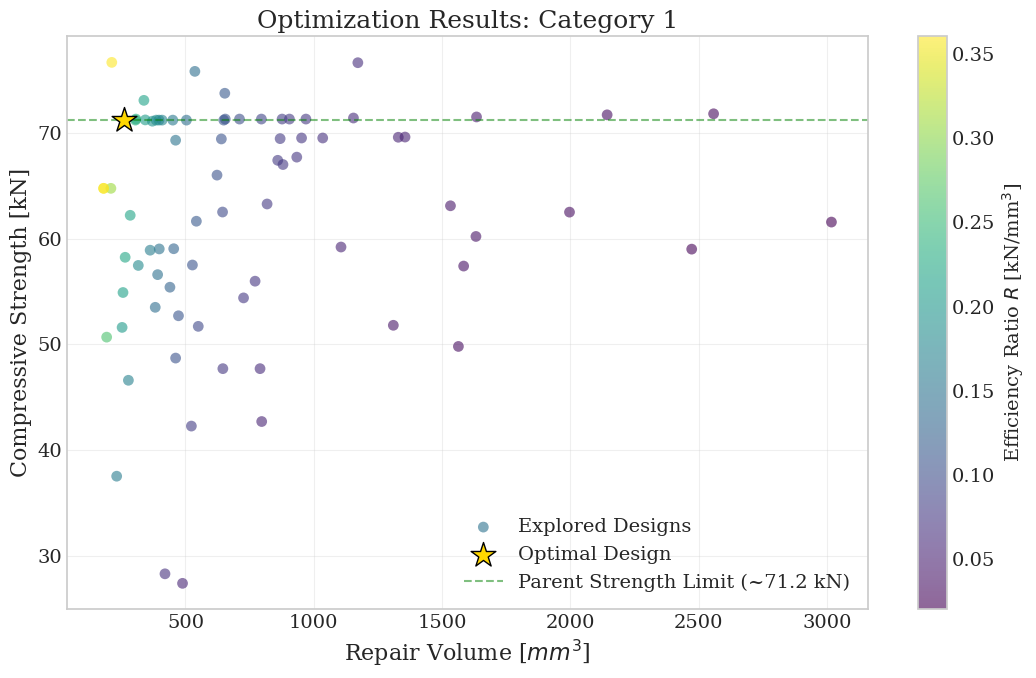

In [45]:
# %% [markdown]
# # Final Engineering Results (Physics-Based Selection with Efficiency Analysis)
# Logic: Since strength saturates at the parent limit (~71.2 kN), the 'Best' design is defined as the Minimum Volume configuration that achieves full strength recovery (> 70 kN).
# We also analyze the Structural Efficiency Ratio (R = Strength / Volume).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": (11, 8) # Slightly wider for colorbar
})

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- HELPER FUNCTIONS ---

def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3)."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def get_pareto_front(df):
    """Identifies Pareto efficient points."""
    costs = df[['Volume_mm3', 'Strength']].values.copy()
    costs[:, 1] = -costs[:, 1] 
    
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0
    
    while next_point_index < len(costs):
        nondominated_point_mask = np.any(costs < costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index]) + 1
        
    mask = np.zeros(n_points, dtype=bool)
    mask[is_efficient] = True
    return mask

def find_best_physics_design(df_pareto, strength_threshold=70.0):
    """
    Finds the Best Design based on Physical Saturation.
    Criteria:
    1. Must have Strength >= Threshold (Full Recovery).
    2. Minimize Volume among those candidates.
    """
    # Filter for full strength recovery
    high_strength = df_pareto[df_pareto['Strength'] >= strength_threshold]

    high_strength = high_strength[high_strength['Strength'] <= 73]
    
    if len(high_strength) > 0:
        # Pick smallest volume among the strong ones
        best_design = high_strength.sort_values('Volume_mm3').iloc[0]
        print(f"Selection Logic: Min Volume with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just pick the absolute strongest point found
        best_design = df_pareto.sort_values('Strength', ascending=False).iloc[0]
        print(f"Selection Logic: Fallback (Max Strength) - Threshold {strength_threshold} kN not met.")
        
    return best_design

# --- EXECUTION FOR CATEGORY 0 ---
CATEGORY = 1
file_path = 'Data_v4.xlsx'
sheet_name = f'Elips{CATEGORY}'

# 1. Load Data
try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df.dropna(subset=['Strength']) 
    print(f"Loaded {len(df)} samples from {sheet_name}")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Calculate Volume (Corrected with Ply Thickness)
    ply_thickness = config['OPTIMIZATION']['THICKNESS_CONSTANT']
    if 'Volume' not in df.columns or df['Volume'].isna().all():
        df['Volume_mm3'] = calculate_volume(df, ply_thickness=ply_thickness)
    else:
        df['Volume_mm3'] = df['Volume']

    # 3. Calculate Ratio R
    df['Ratio'] = df['Strength'] / df['Volume_mm3']

    # 4. Identify Pareto Front
    df['is_pareto'] = get_pareto_front(df)
    pareto_set = df[df['is_pareto']].sort_values('Volume_mm3')

    # 5. Find Best Candidate (Physics Strategy)
    # Threshold set to 70.0 kN based on parent strength saturation ~71.2
    best_design = find_best_physics_design(df, strength_threshold=70.0)

    print(f"\n--- OPTIMAL DESIGN (CATEGORY {CATEGORY}) ---")
    print(f"ID: {best_design.get('Specimen_ID', 'Unknown')}")
    print(f"Strength: {best_design['Strength']:.2f} kN")
    print(f"Volume:   {best_design['Volume_mm3']:.2f} mm3")
    print(f"Ratio R:  {best_design['Ratio']:.4f} kN/mm3")
    print("Geometry (a_i):", [best_design[f'a_ply{i}'] for i in range(1,7)])
    print("Geometry (b_i):", [best_design[f'b_ply{i}'] for i in range(1,7)])

    # --- PLOTTING ---
    plt.figure(figsize=(11, 7))

    # Plot All Points - Color mapped by Ratio R
    sc = plt.scatter(df['Volume_mm3'], df['Strength'], 
                     c=df['Ratio'], cmap='viridis', 
                     alpha=0.6, s=60, edgecolors='none', label='Explored Designs')
    
    # Add Colorbar for R
    cbar = plt.colorbar(sc)
    cbar.set_label('Efficiency Ratio $R$ [kN/mm$^3$]', fontsize=14)

    # # Plot Pareto Front (Line)
    # plt.plot(pareto_set['Volume_mm3'], pareto_set['Strength'], 
    #          'r-', lw=2.5, alpha=0.8, label='Pareto Front')
    
    # # Plot Pareto Points (Dots - Keep Red for visibility or match colormap?)
    # # Keeping red to distinctively mark the front
    # plt.scatter(pareto_set['Volume_mm3'], pareto_set['Strength'], 
    #             c='red', s=80, edgecolors='k', zorder=5)

    # Highlight Best Point (Star)
    plt.scatter(best_design['Volume_mm3'], best_design['Strength'], 
                c='gold', marker='*', s=350, edgecolors='k', zorder=10, 
                label='Optimal Design')
    
    # Draw Threshold Line
    plt.axhline(y=71.2, color='green', linestyle='--', alpha=0.5, label='Parent Strength Limit (~71.2 kN)')

    plt.xlabel('Repair Volume [$mm^3$]')
    plt.ylabel('Compressive Strength [kN]')
    plt.title(f'Optimization Results: Category {CATEGORY}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'final_result_cat{CATEGORY}_physics.png', dpi=300)
    plt.show()

Loaded 78 samples from Elips1
Selection Logic: Min Volume with Strength >= 70.0 kN

--- OPTIMAL DESIGN (CATEGORY 1) ---
ID: Specimen_10
Strength: 76.66 kN
Volume:   212.79 mm3
Geometry (a_i): [6.3, 7.5, 8.8, 10.0, 11.3, 12.6]
Geometry (b_i): [5, 5.5, 6.0, 6.5, 7.0, 7.5]


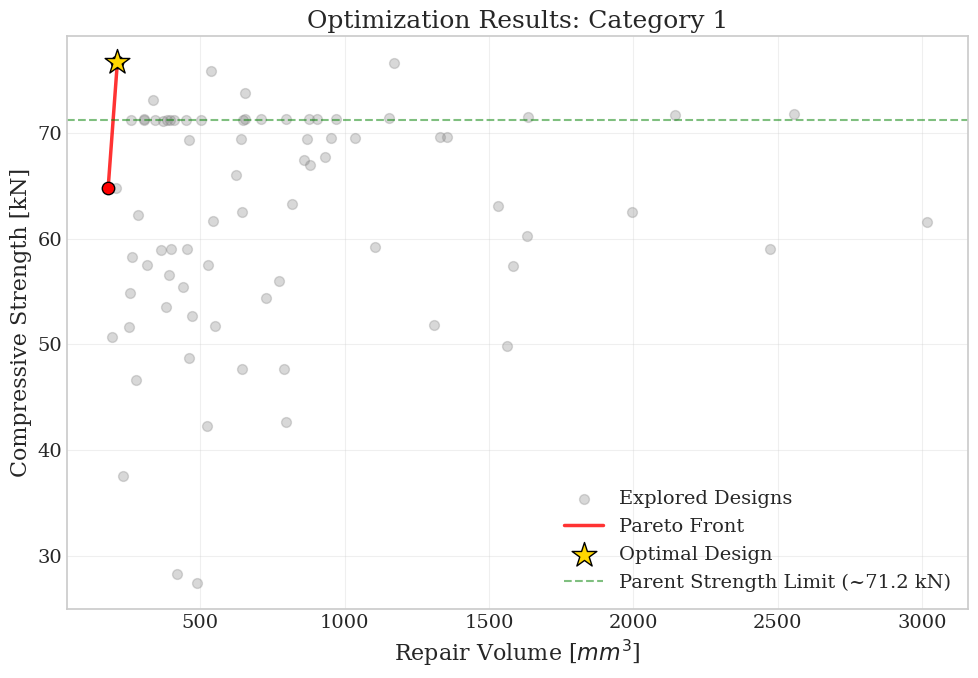

In [46]:
# %% [markdown]
# # Final Engineering Results (Physics-Based Selection) - Category 1
# Logic: Since strength saturates at the parent limit (~71.2 kN), the 'Best' design is defined as the Minimum Volume configuration that achieves full strength recovery (> 70 kN).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": (10, 7)
})

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- HELPER FUNCTIONS ---

def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3)."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def get_pareto_front(df):
    """Identifies Pareto efficient points."""
    costs = df[['Volume_mm3', 'Strength']].values.copy()
    costs[:, 1] = -costs[:, 1] 
    
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0
    
    while next_point_index < len(costs):
        nondominated_point_mask = np.any(costs < costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index]) + 1
        
    mask = np.zeros(n_points, dtype=bool)
    mask[is_efficient] = True
    return mask

def find_best_physics_design(df_pareto, strength_threshold=70.0):
    """
    Finds the Best Design based on Physical Saturation.
    Criteria:
    1. Must have Strength >= Threshold (Full Recovery).
    2. Minimize Volume among those candidates.
    """
    # Filter for full strength recovery
    high_strength = df_pareto[df_pareto['Strength'] >= strength_threshold]
    
    if len(high_strength) > 0:
        # Pick smallest volume among the strong ones
        best_design = high_strength.sort_values('Volume_mm3').iloc[0]
        print(f"Selection Logic: Min Volume with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just pick the absolute strongest point found
        best_design = df_pareto.sort_values('Strength', ascending=False).iloc[0]
        print(f"Selection Logic: Fallback (Max Strength) - Threshold {strength_threshold} kN not met.")
        
    return best_design

# --- EXECUTION FOR CATEGORY 1 ---
CATEGORY = 1
file_path = 'Data_v4.xlsx'
sheet_name = f'Elips{CATEGORY}'

# 1. Load Data
try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df.dropna(subset=['Strength']) 
    print(f"Loaded {len(df)} samples from {sheet_name}")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Calculate Volume (Corrected with Ply Thickness)
    ply_thickness = config['OPTIMIZATION']['THICKNESS_CONSTANT']
    if 'Volume' not in df.columns or df['Volume'].isna().all():
        df['Volume_mm3'] = calculate_volume(df, ply_thickness=ply_thickness)
    else:
        df['Volume_mm3'] = df['Volume']

    # 3. Identify Pareto Front
    df['is_pareto'] = get_pareto_front(df)
    pareto_set = df[df['is_pareto']].sort_values('Volume_mm3')

    # 4. Find Best Candidate (Physics Strategy)
    # Threshold set to 70.0 kN based on parent strength saturation ~71.2
    best_design = find_best_physics_design(pareto_set, strength_threshold=70.0)

    print(f"\n--- OPTIMAL DESIGN (CATEGORY {CATEGORY}) ---")
    print(f"ID: {best_design.get('Specimen_ID', 'Unknown')}")
    print(f"Strength: {best_design['Strength']:.2f} kN")
    print(f"Volume:   {best_design['Volume_mm3']:.2f} mm3")
    print("Geometry (a_i):", [best_design[f'a_ply{i}'] for i in range(1,7)])
    print("Geometry (b_i):", [best_design[f'b_ply{i}'] for i in range(1,7)])

    # --- PLOTTING ---
    plt.figure(figsize=(10, 7))

    # Plot All Points
    plt.scatter(df['Volume_mm3'], df['Strength'], 
                c='gray', alpha=0.3, s=50, label='Explored Designs')

    # Plot Pareto Front
    plt.plot(pareto_set['Volume_mm3'], pareto_set['Strength'], 
             'r-', lw=2.5, alpha=0.8, label='Pareto Front')
    plt.scatter(pareto_set['Volume_mm3'], pareto_set['Strength'], 
                c='red', s=80, edgecolors='k', zorder=5)

    # Highlight Best Point
    plt.scatter(best_design['Volume_mm3'], best_design['Strength'], 
                c='gold', marker='*', s=350, edgecolors='k', zorder=10, 
                label='Optimal Design')
    
    # Draw Threshold Line
    plt.axhline(y=71.2, color='green', linestyle='--', alpha=0.5, label='Parent Strength Limit (~71.2 kN)')

    plt.xlabel('Repair Volume [$mm^3$]')
    plt.ylabel('Compressive Strength [kN]')
    plt.title(f'Optimization Results: Category {CATEGORY}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'final_result_cat{CATEGORY}_physics.png', dpi=300)
    plt.show()

In [47]:
# %% [markdown]
# # Final Candidate Selection (Global Minimum Volume)
# Selects the top 3 designs from the ENTIRE dataset that meet the strength requirement (>70 kN) with minimal volume.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
PLY_THICKNESS = 0.187 # mm

# --- HELPER FUNCTIONS ---
def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3) from ply dimensions."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def find_top_candidates_global(df, strength_threshold=70.0, top_n=3):
    """
    Finds Top N Designs from ALL data points (Global Search).
    Criteria:
    1. Strength >= Threshold (Full Recovery)
    2. Minimize Volume among these candidates.
    """
    # Filter full dataset for sufficient strength
    high_strength = df[df['Strength'] >= strength_threshold].copy()
    
    if len(high_strength) > 0:
        # Sort by Volume ascending (Min Volume is best)
        top_candidates = high_strength.sort_values('Volume_mm3', ascending=True).head(top_n)
        print(f"Selection Logic: Top {top_n} from GLOBAL set with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just strongest points overall
        top_candidates = df.sort_values('Strength', ascending=False).head(top_n)
        print("Selection Logic: Fallback (Max Strength) - Threshold not met.")
        
    return top_candidates

# --- EXECUTION ---
for CATEGORY in [0, 1]:
    file_path = f'Data_v4.xlsx'
    sheet_name = f'Elips{CATEGORY}'
    
    print(f"\n{'='*40}\nANALYZING CATEGORY {CATEGORY}\n{'='*40}")
    
    # 1. Load Data
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.dropna(subset=['Strength'])
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        continue

    # 2. Force Volume Calculation & Ratio
    df['Volume_mm3'] = calculate_volume(df, PLY_THICKNESS)
    df['Ratio'] = df['Strength'] / df['Volume_mm3']

    # 3. Find Top 3 Candidates (Global Logic)
    top_designs = find_top_candidates_global(df, strength_threshold=70.0, top_n=6)

    # 4. Display Results
    print(f"\n--- TOP 4 CANDIDATES (CATEGORY {CATEGORY}) ---")
    
    disp_cols = ['Specimen_ID', 'Strength', 'Volume_mm3', 'Ratio']
    print(top_designs[disp_cols].to_string(index=False))
    
    print("\n--- GEOMETRY PARAMETERS ---")
    for idx, row in top_designs.iterrows():
        sid = row['Specimen_ID']
        a_vals = [round(row[f'a_ply{i}'], 2) for i in range(1,7)]
        b_vals = [round(row[f'b_ply{i}'], 2) for i in range(1,7)]
        print(f"{sid}:")
        print(f"  a = {a_vals}")
        print(f"  b = {b_vals}")


ANALYZING CATEGORY 0
Selection Logic: Top 6 from GLOBAL set with Strength >= 70.0 kN

--- TOP 4 CANDIDATES (CATEGORY 0) ---
Specimen_ID  Strength  Volume_mm3    Ratio
Specimen_47     71.20  214.429407 0.332044
Specimen_16     71.23  234.991130 0.303118
Specimen_87     71.20  236.166086 0.301483
Specimen_80     71.20  241.453387 0.294881
Specimen_61     71.20  252.615465 0.281851
Specimen_72     71.20  258.490244 0.275446

--- GEOMETRY PARAMETERS ---
Specimen_47:
  a = [5.0, 6.0, 7.0, 8.0, 9.0, 11.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 10.0]
Specimen_16:
  a = [6.0, 7.0, 8.0, 9.0, 10.0, 11.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 10.0]
Specimen_87:
  a = [5.0, 6.0, 7.0, 9.0, 10.0, 13.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 10.0]
Specimen_80:
  a = [5.0, 6.0, 7.0, 8.0, 9.0, 13.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 12.0]
Specimen_61:
  a = [5.0, 6.0, 7.0, 8.0, 10.0, 13.0]
  b = [5, 6.0, 7.0, 8.0, 10.0, 12.0]
Specimen_72:
  a = [5.0, 7.0, 8.0, 9.0, 10.0, 11.0]
  b = [5, 7.0, 8.0, 9.0, 10.0, 11.0]

ANALYZING CATEGO

In [48]:
# %% [markdown]
# ## Quality Check: Duplicate Design Detection
# Checks each sheet in the dataset for specimens with identical geometric parameters.

# %%
import pandas as pd

def check_design_duplicates(file_path):
    print(f"--- Checking for Duplicates in '{file_path}' ---")
    
    try:
        xls = pd.ExcelFile(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        
        # 1. Identify Design Columns (a_ply... and b_ply...)
        design_cols = [c for c in df.columns if c.startswith(('a_ply', 'b_ply'))]
        
        if not design_cols:
            print(f"[Sheet: {sheet}] No design parameters found. Skipping.")
            continue
            
        # 2. Find Duplicates
        # keep=False marks ALL duplicates as True (so we can count them all)
        dupes = df[df.duplicated(subset=design_cols, keep=False)]
        
        if len(dupes) > 0:
            print(f"\n[Sheet: {sheet}] ⚠️ FOUND {len(dupes)} DUPLICATE ROWS!")
            
            # Group by geometry to show which IDs are colliding
            dupes_grouped = dupes.groupby(design_cols)['Specimen_ID'].apply(list)
            for geom, ids in dupes_grouped.items():
                print(f"  -> Identical Geometry shared by IDs: {ids}")
        else:
            print(f"[Sheet: {sheet}] ✅ No duplicates found.")

# --- EXECUTE CHECK ---
check_design_duplicates('Data_v4.xlsx')

--- Checking for Duplicates in 'Data_v4.xlsx' ---
[Sheet: Elips0] ✅ No duplicates found.
[Sheet: Elips1] ✅ No duplicates found.


In [51]:
import pandas as pd
import numpy as np
import re

# ==========================================
# CONFIGURATION
# ==========================================
FILE_PATH = 'Data_v4.xlsx'
SHEET_NAMES = ['Elips0', 'Elips1']
CATEGORY_IDS = [0, 1]

# AL_START: The specific Specimen_ID where Run 1 begins.
CONFIG = {
    0: {'AL_START': 39, 'BEST_ID': 47},
    1: {'AL_START': 42, 'BEST_ID': 87}
}

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def extract_id(val):
    """
    Parses 'Specimen_39' -> 39 (int).
    Returns 0 if it fails.
    """
    try:
        if isinstance(val, str):
            match = re.search(r'(\d+)', val)
            if match:
                return int(match.group(1))
        return int(val) 
    except:
        return 0

def load_and_assign_runs(file_path, sheet_name, cat_id, al_start):
    """
    Loads data and creates the 'Run' column based on AL_START.
    """
    try:
        # 1. Load Excel
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # 2. Extract the Raw Integer ID (e.g., 35, 36, 39...)
        if 'Specimen_ID' in df.columns:
            df['Raw_ID'] = df['Specimen_ID'].apply(extract_id)
        else:
            # Fallback if column missing
            df['Raw_ID'] = np.arange(1, len(df) + 1)

        # 3. Create the 'Run' Column
        # Logic: 
        #   If Raw_ID < AL_START  --> Run = 0
        #   If Raw_ID >= AL_START --> Run = (Raw_ID - AL_START) + 1
        df['Run'] = df['Raw_ID'].apply(lambda x: 0 if x < al_start else x - al_start + 1)

        # 4. Sort and return
        df = df.sort_values('Raw_ID')
        print(f"Loaded {sheet_name} (Cat {cat_id}). Found {len(df)} rows.")
        return df

    except Exception as e:
        print(f"Error loading {sheet_name}: {e}")
        return pd.DataFrame()

# ==========================================
# VERIFICATION (Try it out)
# ==========================================
# This loop loads the data and prints a preview to check the Run column logic
for i, cat_id in enumerate(CATEGORY_IDS):
    al_start = CONFIG[cat_id]['AL_START']
    
    # Load
    df = load_and_assign_runs(FILE_PATH, SHEET_NAMES[i], cat_id, al_start)
    
    if not df.empty:
        # Check the transition point (around AL_START)
        # We look for rows where Raw_ID is close to the start point
        subset = df[(df['Raw_ID'] >= al_start - 2) & (df['Raw_ID'] <= al_start + 2)]
        
        print(f"\n--- Check Logic for Category {cat_id} (Start: {al_start}) ---")
        print(subset[['Specimen_ID', 'Raw_ID', 'Run']].to_string(index=False))

Loaded Elips0 (Cat 0). Found 92 rows.

--- Check Logic for Category 0 (Start: 39) ---
Specimen_ID  Raw_ID  Run
Specimen_37      37    0
Specimen_38      38    0
Specimen_39      39    1
Specimen_40      40    2
Specimen_41      41    3
Loaded Elips1 (Cat 1). Found 78 rows.

--- Check Logic for Category 1 (Start: 42) ---
Specimen_ID  Raw_ID  Run
Specimen_42      42    1
Specimen_44      44    3



--- Processing Category 0 ---
Plot saved successfully as: parameter_evolution_cat0.png


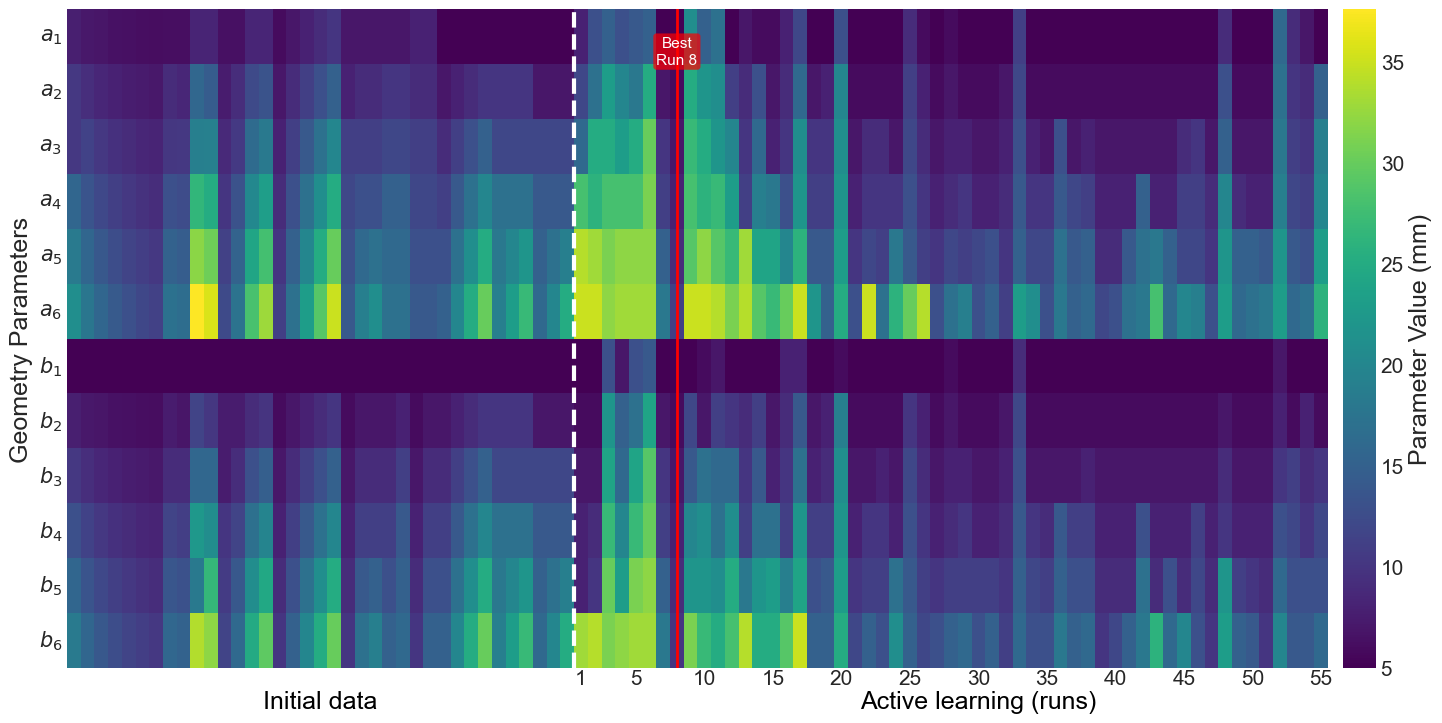


--- Processing Category 1 ---
Plot saved successfully as: parameter_evolution_cat1.png


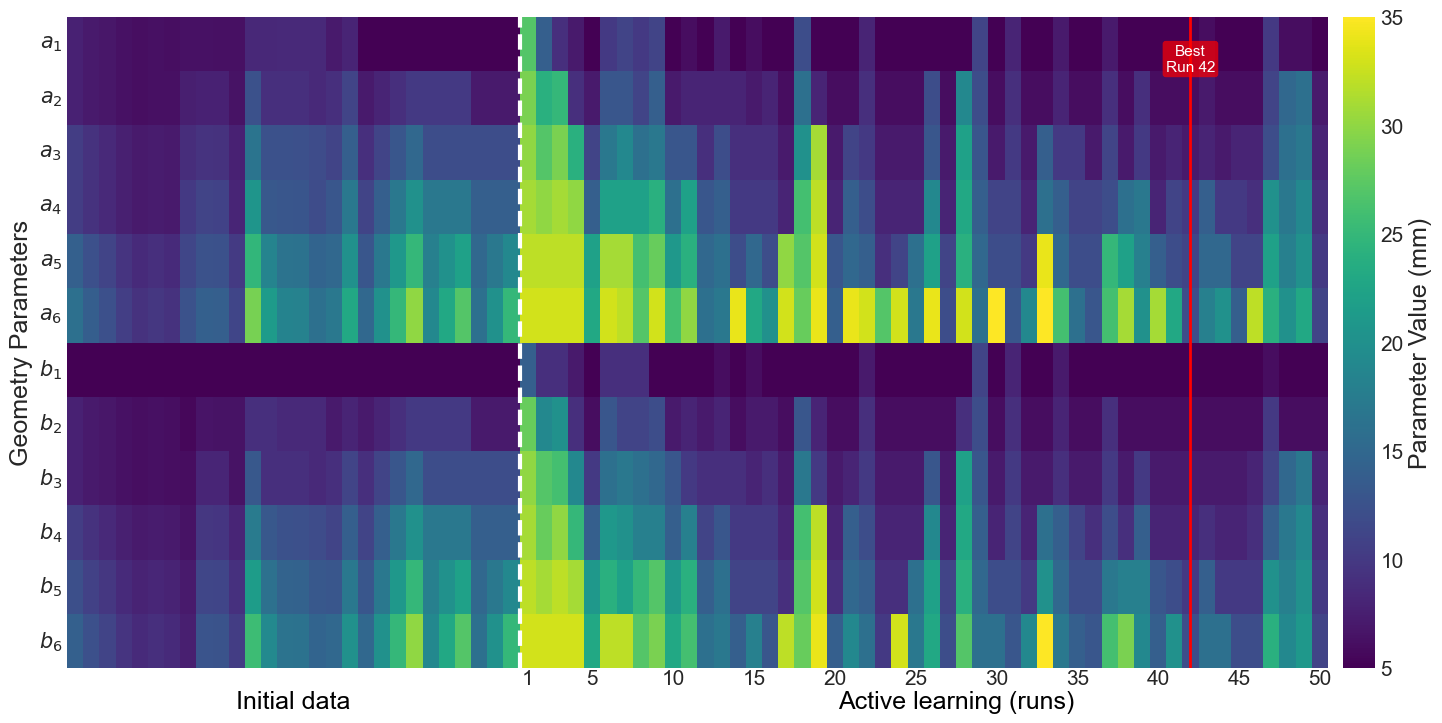

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# ==========================================
# 0. CONFIGURATION
# ==========================================
CATEGORY_IDS = [0, 1] 
SHEET_NAMES = ['Elips0', 'Elips1']
FILE_PATH = 'Data_v4.xlsx'

CONFIG = {
    0: {'AL_START': 39, 'BEST_ID': 47},
    1: {'AL_START': 42, 'BEST_ID': 87}
}

# ==========================================
# 1. DATA LOADING
# ==========================================
def extract_id(val):
    try:
        if isinstance(val, str):
            match = re.search(r'(\d+)', val)
            if match:
                return int(match.group(1))
        return int(val) 
    except:
        return 0

def load_category_data(file_path, sheet_name, category_id):
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        if 'Specimen_ID' in df.columns:
            df['Raw_ID'] = df['Specimen_ID'].apply(extract_id)
        else:
            df['Raw_ID'] = np.arange(1, len(df) + 1)
        df['Category'] = f'Cat {category_id}'
        return df.sort_values('Raw_ID')
    except Exception as e:
        print(f"Error loading {sheet_name}: {e}")
        return pd.DataFrame()

# ==========================================
# 2. PLOTTING FUNCTION
# ==========================================
def plot_dna_final_v3(category_id, df, al_start_id, best_id):
    if df.empty:
        return

    # --- A. Prepare Data ---
    param_cols = [f'a_ply{i}' for i in range(1, 7)] + [f'b_ply{i}' for i in range(1, 7)]
    df_melted = df.melt(id_vars=['Raw_ID'], value_vars=param_cols, var_name='Param', value_name='Value')
    heatmap_data = df_melted.pivot_table(index='Param', columns='Raw_ID', values='Value')
    
    # Sort and Rename Y-Axis
    original_order = [f'a_ply{i}' for i in range(1,7)] + [f'b_ply{i}' for i in range(1,7)]
    heatmap_data = heatmap_data.reindex(original_order)
    
    y_labels_map = {f'a_ply{i}': f'$a_{{{i}}}$' for i in range(1, 7)}
    y_labels_map.update({f'b_ply{i}': f'$b_{{{i}}}$' for i in range(1, 7)})
    heatmap_data.rename(index=y_labels_map, inplace=True)

    col_ids = heatmap_data.columns.tolist()
    n_rows = len(heatmap_data) 

    # --- B. Calculate Labels (Sequential) ---
    custom_labels = []
    ticks_pos = []
    
    al_specimens = [uid for uid in col_ids if uid >= al_start_id]
    al_run_map = {uid: i+1 for i, uid in enumerate(al_specimens)}

    try:
        sep_idx = col_ids.index(al_specimens[0]) if al_specimens else len(col_ids)
    except ValueError:
        sep_idx = 0

    for i, spec_id in enumerate(col_ids):
        ticks_pos.append(i + 0.5)
        if spec_id < al_start_id:
            custom_labels.append('') 
        else:
            seq_run = al_run_map[spec_id]
            if seq_run == 1:
                custom_labels.append('1')
            elif seq_run % 5 == 0:
                custom_labels.append(str(seq_run))
            else:
                custom_labels.append('')

    # --- C. Plotting ---
    plt.style.use('seaborn-v0_8-white')
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Heatmap with tighter colorbar
    sns.heatmap(heatmap_data, cmap='viridis', ax=ax1, 
                cbar_kws={'label': 'Parameter Value (mm)', 'pad': 0.01})
    
    # Fonts: Colorbar
    cbar = ax1.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15) 
    cbar.set_label('Parameter Value (mm)', fontsize=18)

    # 1. Separator Line
    ax1.axvline(x=sep_idx, color='white', linestyle='--', linewidth=3)

    # 2. Bottom Region Labels
    label_y_pos = n_rows + 0.4
    
    if sep_idx > 0:
        ax1.text(sep_idx / 2, label_y_pos, 'Initial data', 
                 color='black', fontsize=18, ha='center', va='top')

    remaining_width = len(col_ids) - sep_idx
    if remaining_width > 0:
        center_al = sep_idx + (remaining_width / 2) + 2
        ax1.text(center_al, label_y_pos, 'Active learning (runs)', 
                 color='black', fontsize=18, ha='center', va='top')

    # 3. Best Design Marker
    if best_id in col_ids:
        best_col_idx = col_ids.index(best_id)
        best_x_pos = best_col_idx + 0.5
        
        if best_id in al_run_map:
            best_label_text = f"Best\nRun {al_run_map[best_id]}"
        else:
            best_label_text = f"Best\nID {best_id}"

        ax1.axvline(x=best_x_pos, color='red', linestyle='-', linewidth=2)
        ax1.text(best_x_pos, 0.5, best_label_text, 
                 color='white', fontsize=11, va='top', ha='center',
                 bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    # 4. Final Formatting
    
    # X-Ticks: Very close (pad=0.5)
    ax1.set_xticks(ticks_pos)
    ax1.set_xticklabels(custom_labels, rotation=0)
    ax1.tick_params(axis='x', which='major', pad=0.5, labelsize=15)
    
    # Y-Ticks
    plt.yticks(rotation=0, fontsize=15)
    
    # Labels
    ax1.set_xlabel('') 
    ax1.set_ylabel('Geometry Parameters', fontsize=18)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15) 
    
    # --- SAVE TO PNG ---
    save_filename = f'parameter_evolution_cat{category_id}.png'
    plt.savefig(save_filename, dpi=600)
    print(f"Plot saved successfully as: {save_filename}")
    
    plt.show()

# ==========================================
# 3. EXECUTION
# ==========================================
for i, cat_id in enumerate(CATEGORY_IDS):
    print(f"\n--- Processing Category {cat_id} ---")
    df_cat = load_category_data(FILE_PATH, SHEET_NAMES[i], cat_id)
    params = CONFIG[cat_id]
    plot_dna_final_v3(cat_id, df_cat, params['AL_START'], params['BEST_ID'])


--- Processing Compact Triplet Category 0 ---
Plot saved: performance_triplet_cat0.png


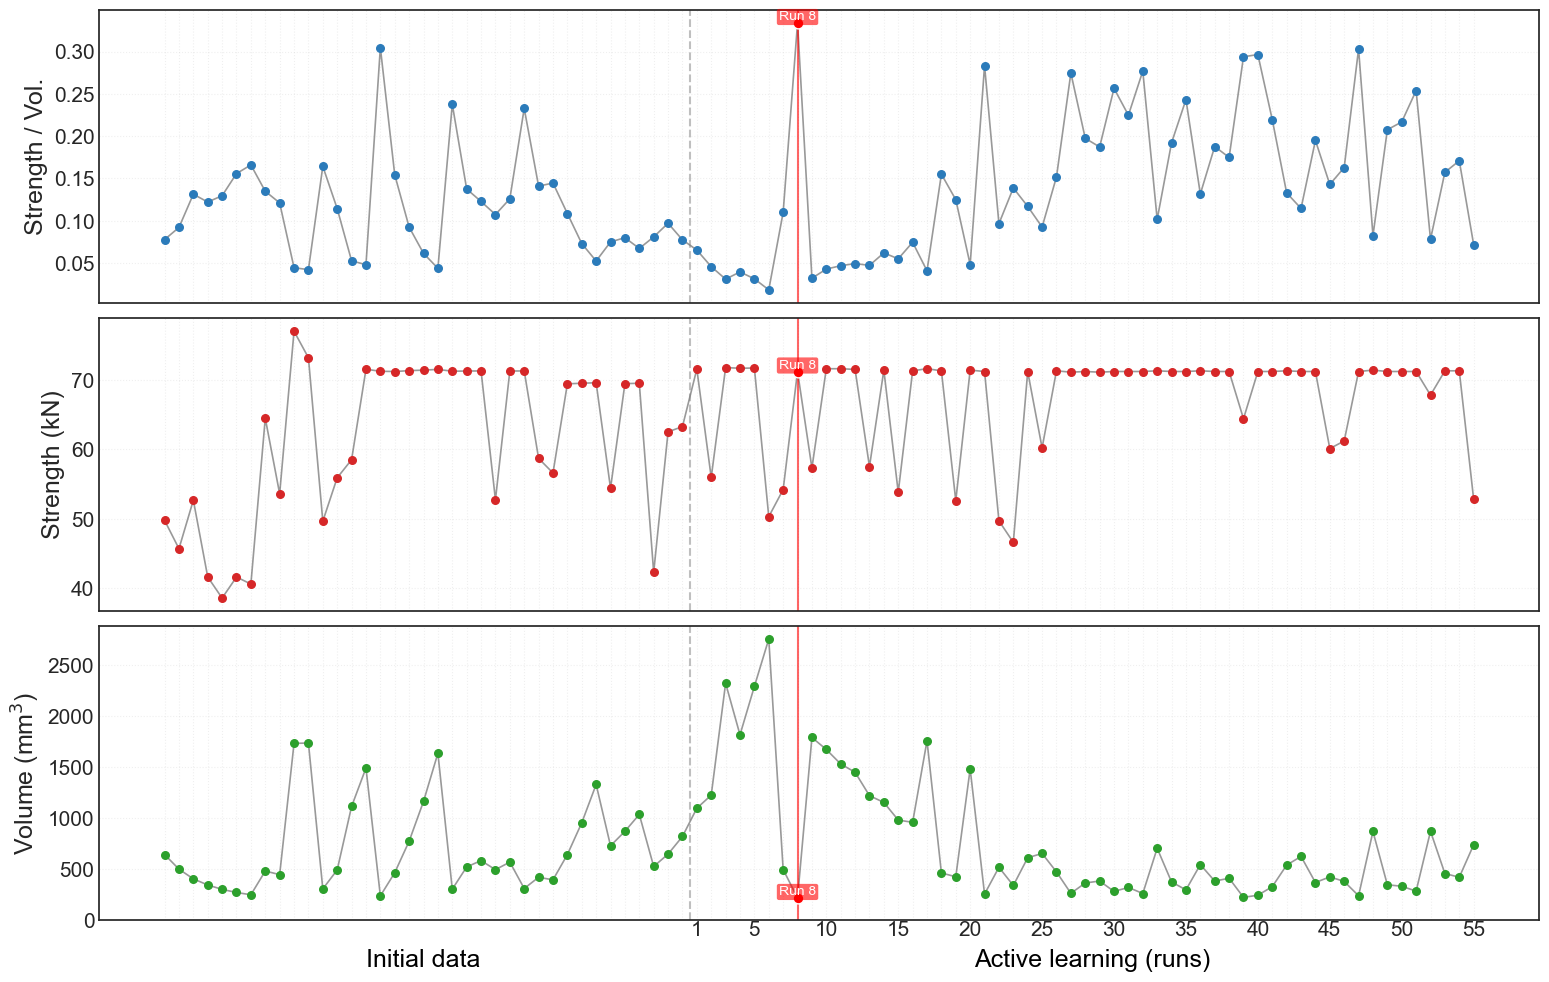


--- Processing Compact Triplet Category 1 ---
Plot saved: performance_triplet_cat1.png


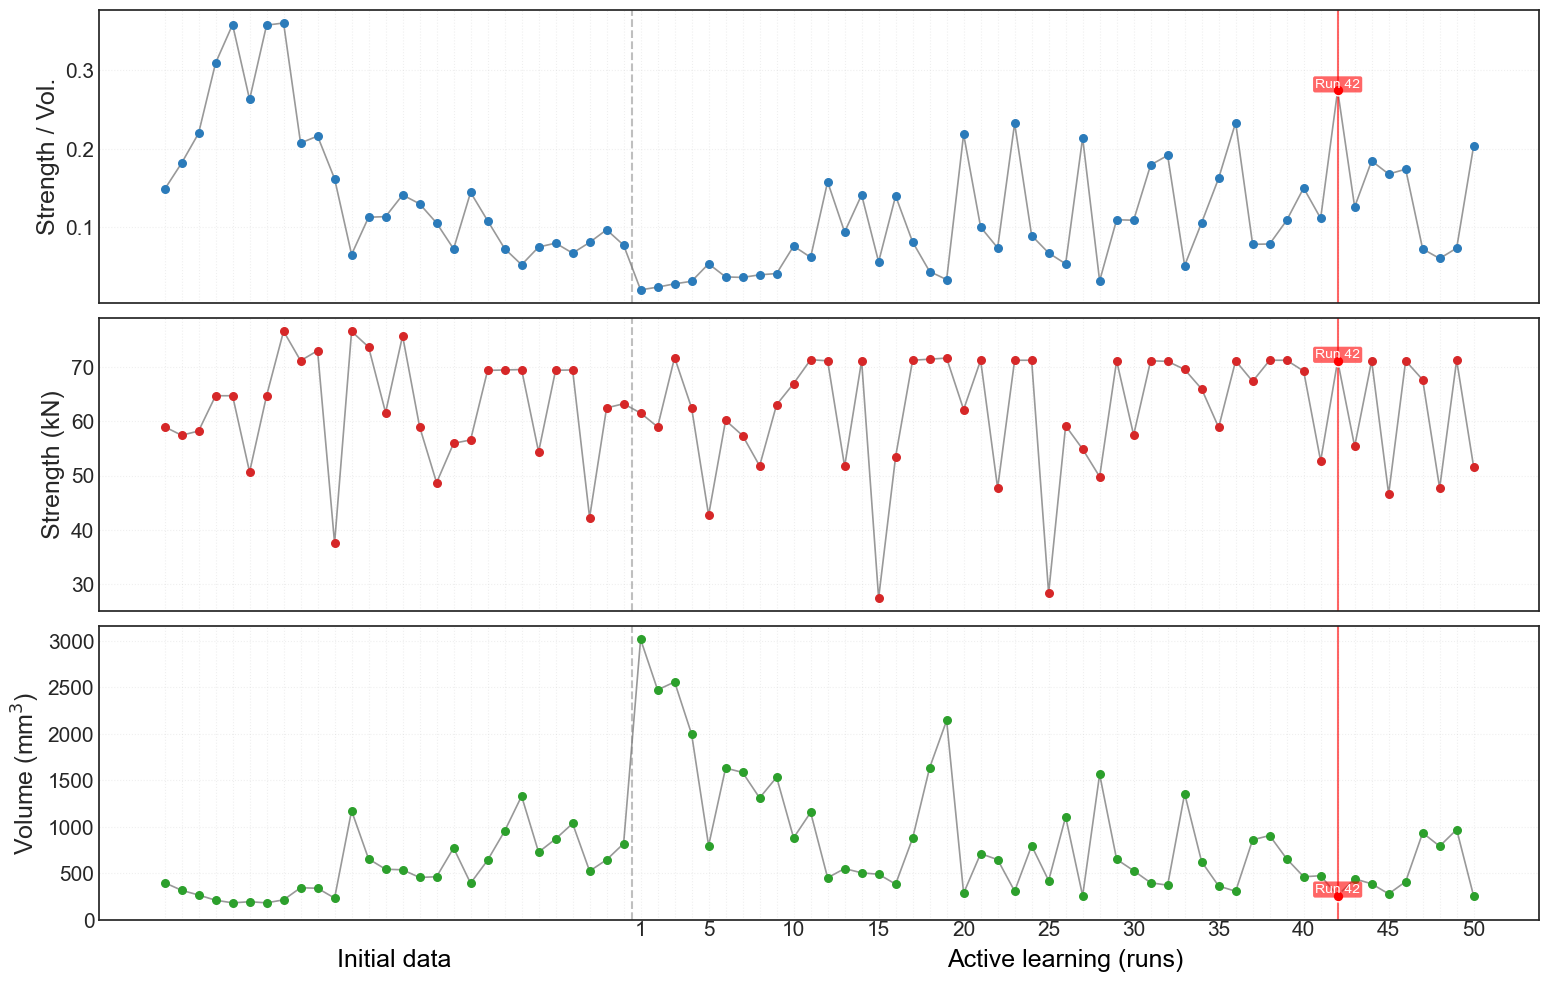

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# ==========================================
# 0. CONFIGURATION
# ==========================================
CATEGORY_IDS = [0, 1] 
SHEET_NAMES = ['Elips0', 'Elips1']
FILE_PATH = 'Data_v4.xlsx'

CONFIG = {
    0: {'AL_START': 39, 'BEST_ID': 47},
    1: {'AL_START': 42, 'BEST_ID': 87}
}

# ==========================================
# 1. DATA LOADING
# ==========================================
def extract_id(val):
    try:
        if isinstance(val, str):
            match = re.search(r'(\d+)', val)
            if match:
                return int(match.group(1))
        return int(val) 
    except:
        return 0

def load_category_data(file_path, sheet_name, category_id):
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        
        if 'Specimen_ID' in df.columns:
            df['Raw_ID'] = df['Specimen_ID'].apply(extract_id)
        else:
            df['Raw_ID'] = np.arange(1, len(df) + 1)
            
        # Ensure Columns Exist
        if 'Strength' not in df.columns: df['Strength'] = 0
        if 'Volume' not in df.columns: df['Volume'] = 1 
            
        df['Ratio'] = df['Strength'] / df['Volume']
        df['Category'] = f'Cat {category_id}'
        
        return df.sort_values('Raw_ID')
    except Exception as e:
        print(f"Error loading {sheet_name}: {e}")
        return pd.DataFrame()

# ==========================================
# 2. PLOTTING FUNCTION (COMPACT TRIPLET)
# ==========================================
def plot_compact_triplet(category_id, df, al_start_id, best_id):
    if df.empty: return

    # --- A. Prepare Data ---
    col_ids = df['Raw_ID'].tolist()
    n_points = len(col_ids)
    
    metrics = [
        ('Ratio', 'Strength / Vol.', '#2b7bba'), # Blue
        ('Strength', 'Strength (kN)', '#d62728'),     # Red
        ('Volume', 'Volume (mm$^3$)', '#2ca02c')          # Green
    ]

    # --- B. Calculate Labels ---
    custom_labels = []
    al_specimens = [uid for uid in col_ids if uid >= al_start_id]
    al_run_map = {uid: i+1 for i, uid in enumerate(al_specimens)}

    try:
        sep_idx = col_ids.index(al_specimens[0]) if al_specimens else len(col_ids)
    except ValueError: sep_idx = 0

    for i, spec_id in enumerate(col_ids):
        if spec_id < al_start_id:
            custom_labels.append('') 
        else:
            seq_run = al_run_map[spec_id]
            if seq_run == 1: custom_labels.append('1')
            elif seq_run % 5 == 0: custom_labels.append(str(seq_run))
            else: custom_labels.append('')

    # --- C. Setup Figure ---
    plt.style.use('seaborn-v0_8-white')
    # Reduced height for compactness, tight hspace
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True, 
                             gridspec_kw={'hspace': 0.05})

    # --- D. Plot Loop ---
    for idx, ax in enumerate(axes):
        col_name, ylabel, line_color = metrics[idx]
        y_values = df[col_name].tolist() if col_name in df.columns else [0]*n_points

        # 1. Plot Line & Scatter
        ax.plot(range(n_points), y_values, color='#555555', linewidth=1.2, alpha=0.6, zorder=1)
        ax.scatter(range(n_points), y_values, color=line_color, s=30, zorder=2)

        # 2. Separator Line
        ax.axvline(x=sep_idx - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

        # 3. Best Design Marker
        if best_id in col_ids:
            best_idx = col_ids.index(best_id)
            best_y = y_values[best_idx]
            
            if best_id in al_run_map: txt = f"Run {al_run_map[best_id]}"
            else: txt = f"ID {best_id}"
            
            ax.axvline(x=best_idx, color='red', linestyle='-', linewidth=1.5, alpha=0.6)
            
            # Place label near the point
            ax.text(best_idx, best_y, txt, color='white', fontsize=10, ha='center', va='bottom',
                    bbox=dict(facecolor='red', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.15'),
                    zorder=5)
            ax.scatter(best_idx, best_y, color='red', s=60, zorder=3, edgecolor='white')

        # 4. Y-Axis Formatting
        ax.set_ylabel(ylabel, fontsize=18)
        ax.tick_params(axis='y', labelsize=15)
        ax.grid(True, linestyle=':', alpha=0.3)
        if col_name == 'Volume': ax.set_ylim(bottom=0)

    # --- E. Bottom X-Axis Formatting ---
    last_ax = axes[-1]
    last_ax.set_xticks(range(n_points))
    last_ax.set_xticklabels(custom_labels, rotation=0)
    # Very close padding
    last_ax.tick_params(axis='x', which='major', pad=0.5, labelsize=15)
    last_ax.set_xlabel('')

    # --- F. Bottom Region Labels ---
    # Use transform to place below the axis
    trans = last_ax.get_xaxis_transform() 
    label_y_pos = -0.1 # Position below ticks
    
    if sep_idx > 0:
        last_ax.text(sep_idx / 2 - 0.5, label_y_pos, 'Initial data', 
                     color='black', fontsize=18, ha='center', va='top', transform=trans)

    rem_w = n_points - sep_idx
    if rem_w > 0:
        last_ax.text(sep_idx + rem_w / 2, label_y_pos, 'Active learning (runs)', 
                     color='black', fontsize=18, ha='center', va='top', transform=trans)

    # Final Layout
    # Adjust bottom to make room for the labels we added outside the axis
    plt.subplots_adjust(top=0.98, bottom=0.07, right=0.98, left=0.08)
    
    # Save
    save_filename = f'performance_triplet_cat{category_id}.png'
    plt.savefig(save_filename, dpi=300)
    print(f"Plot saved: {save_filename}")
    plt.show()

# ==========================================
# 3. EXECUTION
# ==========================================
for i, cat_id in enumerate(CATEGORY_IDS):
    print(f"\n--- Processing Compact Triplet Category {cat_id} ---")
    df_cat = load_category_data(FILE_PATH, SHEET_NAMES[i], cat_id)
    params = CONFIG[cat_id]
    plot_compact_triplet(cat_id, df_cat, params['AL_START'], params['BEST_ID'])